In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data")

Skipping, found downloaded files in "./brain-tumor-mri-dataset" (use force=True to force download)


In [ ]:
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from IPython.display import Image
import imutils

In [ ]:
os.makedirs("/content/Crop-Brain-MRI/", exist_ok=True)
os.makedirs("/content/Crop-Brain-MRI/glioma", exist_ok=True)
os.makedirs("/content/Crop-Brain-MRI/meningioma", exist_ok=True)
os.makedirs("/content/Crop-Brain-MRI/notumor", exist_ok=True)
os.makedirs("/content/Crop-Brain-MRI/pituitary", exist_ok=True)

In [ ]:
os.makedirs("/content/Test-Data", exist_ok=True)
os.makedirs("/content/Test-Data/glioma", exist_ok=True)
os.makedirs("/content/Test-Data/meningioma", exist_ok=True)
os.makedirs("/content/Test-Data/notumor", exist_ok=True)
os.makedirs("/content/Test-Data/pituitary", exist_ok=True)

In [ ]:
train_dir = "/content/brain-tumor-mri-dataset/Training/"
test_dir = "/content/brain-tumor-mri-dataset/Testing/"

In [ ]:
classes = os.listdir("/content/brain-tumor-mri-dataset/Training/")
print("Classes found:", classes)

Classes found: ['pituitary', 'glioma', 'meningioma', 'notumor']


In [ ]:
filepath_dict  ={}

for c in classes:
  filepath_dict[c] = list(map(lambda x : train_dir + c + '/' + x, os.listdir(train_dir + c)))

In [ ]:
No_images_per_class = []
Class_name = []
for i in os.listdir("/content/brain-tumor-mri-dataset/Training"):
  train_class = os.listdir(os.path.join("/content/brain-tumor-mri-dataset/Training", i))
  No_images_per_class.append(len(train_class))
  Class_name.append(i)
  print(f"Number of images in {i} : {len(train_class)}")

Number of images in pituitary : 1400
Number of images in glioma : 1400
Number of images in meningioma : 1400
Number of images in notumor : 1400


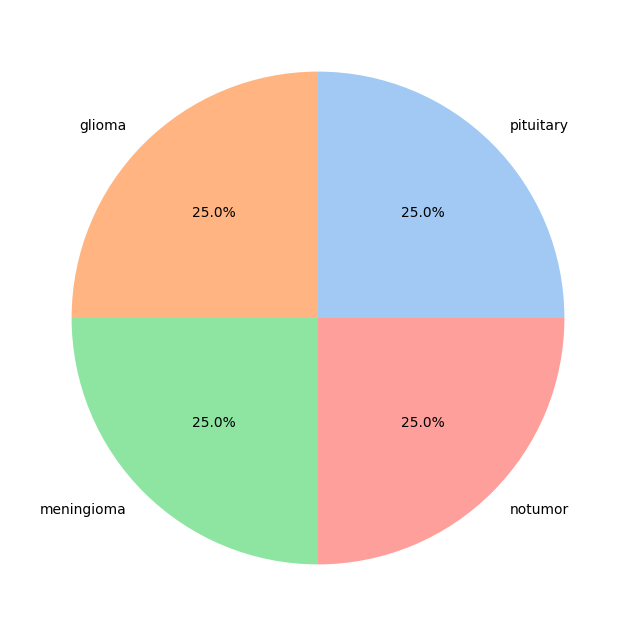

In [ ]:
plt.figure(figsize =(8, 8))
colors = sns.color_palette('pastel')
plt.pie(No_images_per_class, labels = Class_name, autopct = "%1.1f%%", colors = colors)
plt.show()

In [ ]:
def crop_image(image, plot=False):

  img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
  img_thresh = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)[1]
  img_thresh = cv2.erode(img_thresh, None, iterations = 2)
  img_thresh = cv2.dilate(img_thresh, None, iterations = 2)

  contours = cv2.findContours(img_thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

  contours = imutils.grab_contours(contours)

  c = max(contours, key = cv2.contourArea)

  extLeft = tuple(c[c[:, :, 0].argmin()])[0]
  extRight = tuple(c[c[:, :, 0].argmax()])[0]
  extTop = tuple(c[c[:, :, 1].argmin()])[0]
  extBottom = tuple(c[c[:, :, 1].argmax()])[0]

  new_img = image[extTop[1]: extBottom[1], extLeft[0]:extRight[0]]

  if plot:
    plt.figure(figsize = (15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.subplot(1, 2, 2)
    plt.imshow(new_img)
    plt.title("Cropped Image")
    plt.show()
  return new_img


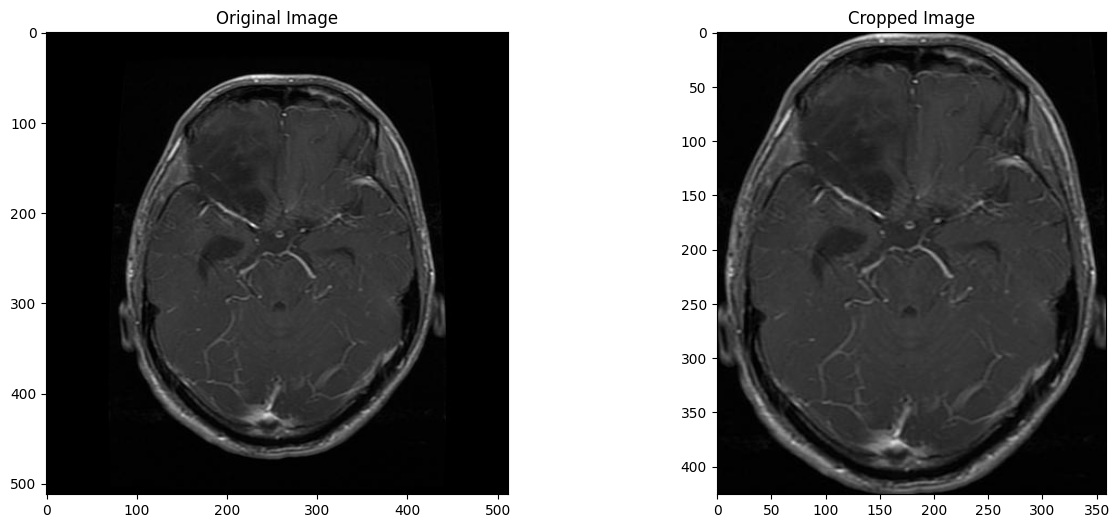

In [ ]:
example_img = cv2.imread("/content/brain-tumor-mri-dataset/Testing/glioma/Te-gl_100.jpg")
cropped_imgs = crop_image(example_img, plot=True)

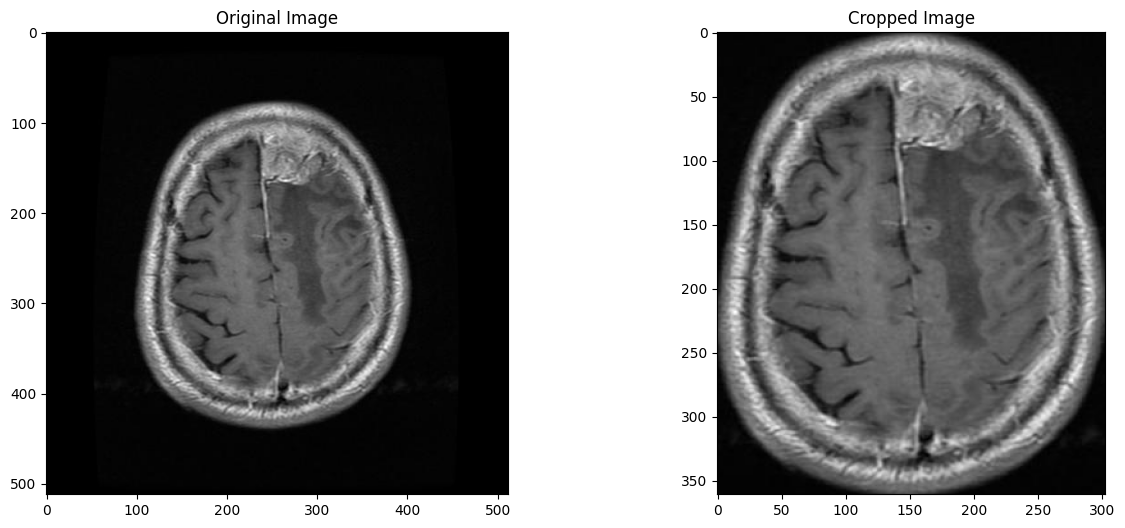

In [ ]:
example_img = cv2.imread("/content/brain-tumor-mri-dataset/Training/meningioma/Tr-me_97.jpg")
cropped_imgs = crop_image(example_img, plot=True)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array

In [ ]:
datagen = ImageDataGenerator(rotation_range = 10,
                             height_shift_range = 0.2,
                             horizontal_flip = True,
                             validation_split = 0.2)

train_data = datagen.flow_from_directory('/content/Crop-Brain-MRI/',
                            target_size = (240, 240),
                            batch_size = 32,
                            class_mode = 'categorical', subset = 'training')

valid_data = datagen.flow_from_directory('/content/Crop-Brain-MRI/',
                            target_size = (240, 240),
                            batch_size = 32,
                            class_mode = 'categorical', subset = 'validation')

test_datagen = ImageDataGenerator()

test_data = datagen.flow_from_directory('/content/Test-Data/',
                            target_size = (240, 240),
                            class_mode = 'categorical', shuffle = False)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
train_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [ ]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

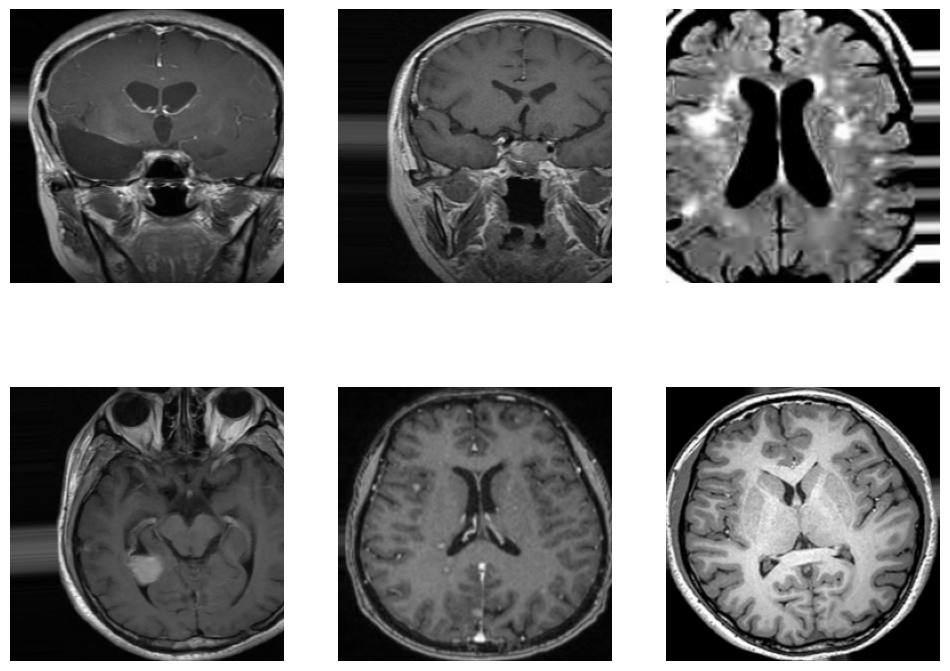

In [ ]:
sample_x, sample_y = next(train_data)

plt.figure(figsize = (12, 9))

for i in range(6):
  plt.subplot(2, 3, i+1)
  sample = array_to_img(sample_x[i])
  plt.axis('off')
  plt.grid(False)
  plt.imshow(sample)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Conv2D, Dropout, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
effenet  = EfficientNetB1(weights = 'imagenet', include_top = False, input_shape = (240, 240, 3))

model = effenet.output
model = GlobalMaxPooling2D()(model)
model = Dropout(0.5)(model)
model = Dense(4, activation="softmax")(model)
model = Model(inputs=effenet.input, outputs = model)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate = 0.0001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
checkpoint = ModelCheckpoint('model.keras', monitor = 'val_accuracy',
                save_best_only = True,
                mode = 'auto',
                verbose = 1)
earlystop = EarlyStopping(monitor = 'val_accuracy',
              patience = 5,
              mode = 'auto', verbose = 1)

reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy',
                  factor = 0.3,
                  patience = 2,
                  min_delta = 0.001,
                  mode = 'auto', verbose = 1)

In [ ]:
%%time
history = model.fit(train_data, epochs = 12, validation_data = valid_data,
                    verbose = 1, callbacks = [checkpoint, earlystop, reduce_lr])

Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.4922 - loss: 3.8857
Epoch 1: val_accuracy improved from None to 0.83304, saving model to model.keras

Epoch 1: finished saving model to model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 218s 712ms/step - accuracy: 0.6366 - loss: 2.5249 - val_accuracy: 0.8330 - val_loss: 0.6024 - learning_rate: 1.0000e-04
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8389 - loss: 0.8918
Epoch 2: val_accuracy improved from 0.83304 to 0.83661, saving model to model.keras

Epoch 2: finished saving model to model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 641ms/step - accuracy: 0.8496 - loss: 0.8100 - val_accuracy: 0.8366 - val_loss: 0.7908 - learning_rate: 1.0000e-04
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.8832 - loss: 0.5581
Epoch 3: val_accuracy improved from 0.83661 to 0.86071, saving model to model.keras

Epoch 3: finished saving model to model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 634ms/step - acc

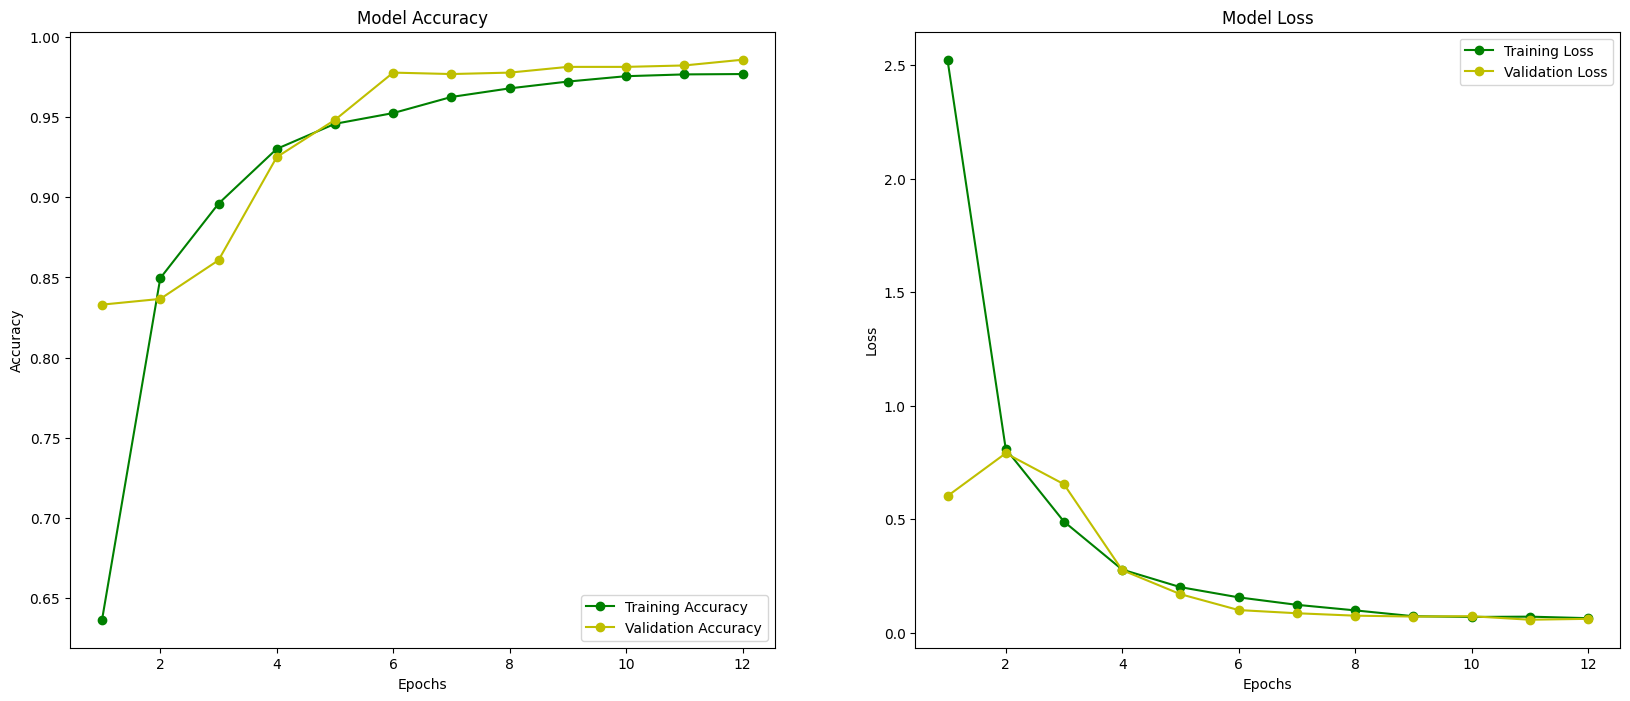

In [ ]:
fig, ax = plt.subplots(1 , 2)
fig.set_size_inches(20, 8)

train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']


epochs = range(1, len(train_acc) + 1)

ax[0].plot(epochs, train_acc, 'g-o', label = 'Training Accuracy')
ax[0].plot(epochs, val_acc, 'y-o', label = 'Validation Accuracy')
ax[0].set_title('Model Accuracy') # Changed title as requested
ax[0].legend(loc = 'lower right')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs, train_loss, 'g-o', label = 'Training Loss') # Changed title as requested
ax[1].plot(epochs, val_loss, 'y-o', label = 'Validation Loss')
ax[1].set_title('Model Loss') # Changed title as requested
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

In [ ]:
model.evaluate(train_data)

140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 453ms/step - accuracy: 0.9971 - loss: 0.0100


[0.010014848783612251, 0.9970982074737549]

In [ ]:
model.evaluate(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.9513 - loss: 0.5666


[0.5666253566741943, 0.9512500166893005]

In [ ]:
y_test = test_data.classes
y_test_hat = np.argmax(model.predict(test_data), axis = 1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 422ms/step


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, classification_report

In [ ]:
cm = confusion_matrix(y_test, y_test_hat)
cm

array([[333,  39,  26,   2],
       [  2, 394,   2,   2],
       [  0,   2, 398,   0],
       [  0,   3,   1, 396]])

In [ ]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

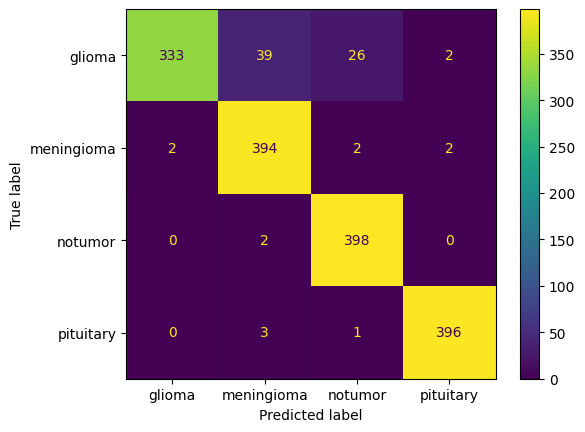

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['glioma', 'meningioma', 'notumor', 'pituitary'])
cm_display.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

           0       0.99      0.83      0.91       400
           1       0.90      0.98      0.94       400
           2       0.93      0.99      0.96       400
           3       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



In [ ]:
import PIL

CLASS_DICT = {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

images = []
prediction = []
original = []

for i in os.listdir('/content/Test-Data'):
  for item in os.listdir(os.path.join('/content/Test-Data', i)):
    img = PIL.Image.open(os.path.join('/content/Test-Data', i, item))
    images.append(img)
    img = np.expand_dims(img, axis = 0)
    # Suppress verbose output from model.predict
    predict = model.predict(img, verbose=0)
    predict = np.argmax(predict)
    prediction.append(CLASS_DICT[predict])
    original.append(i)


In [ ]:
score = accuracy_score(original, prediction)
score

0.94125

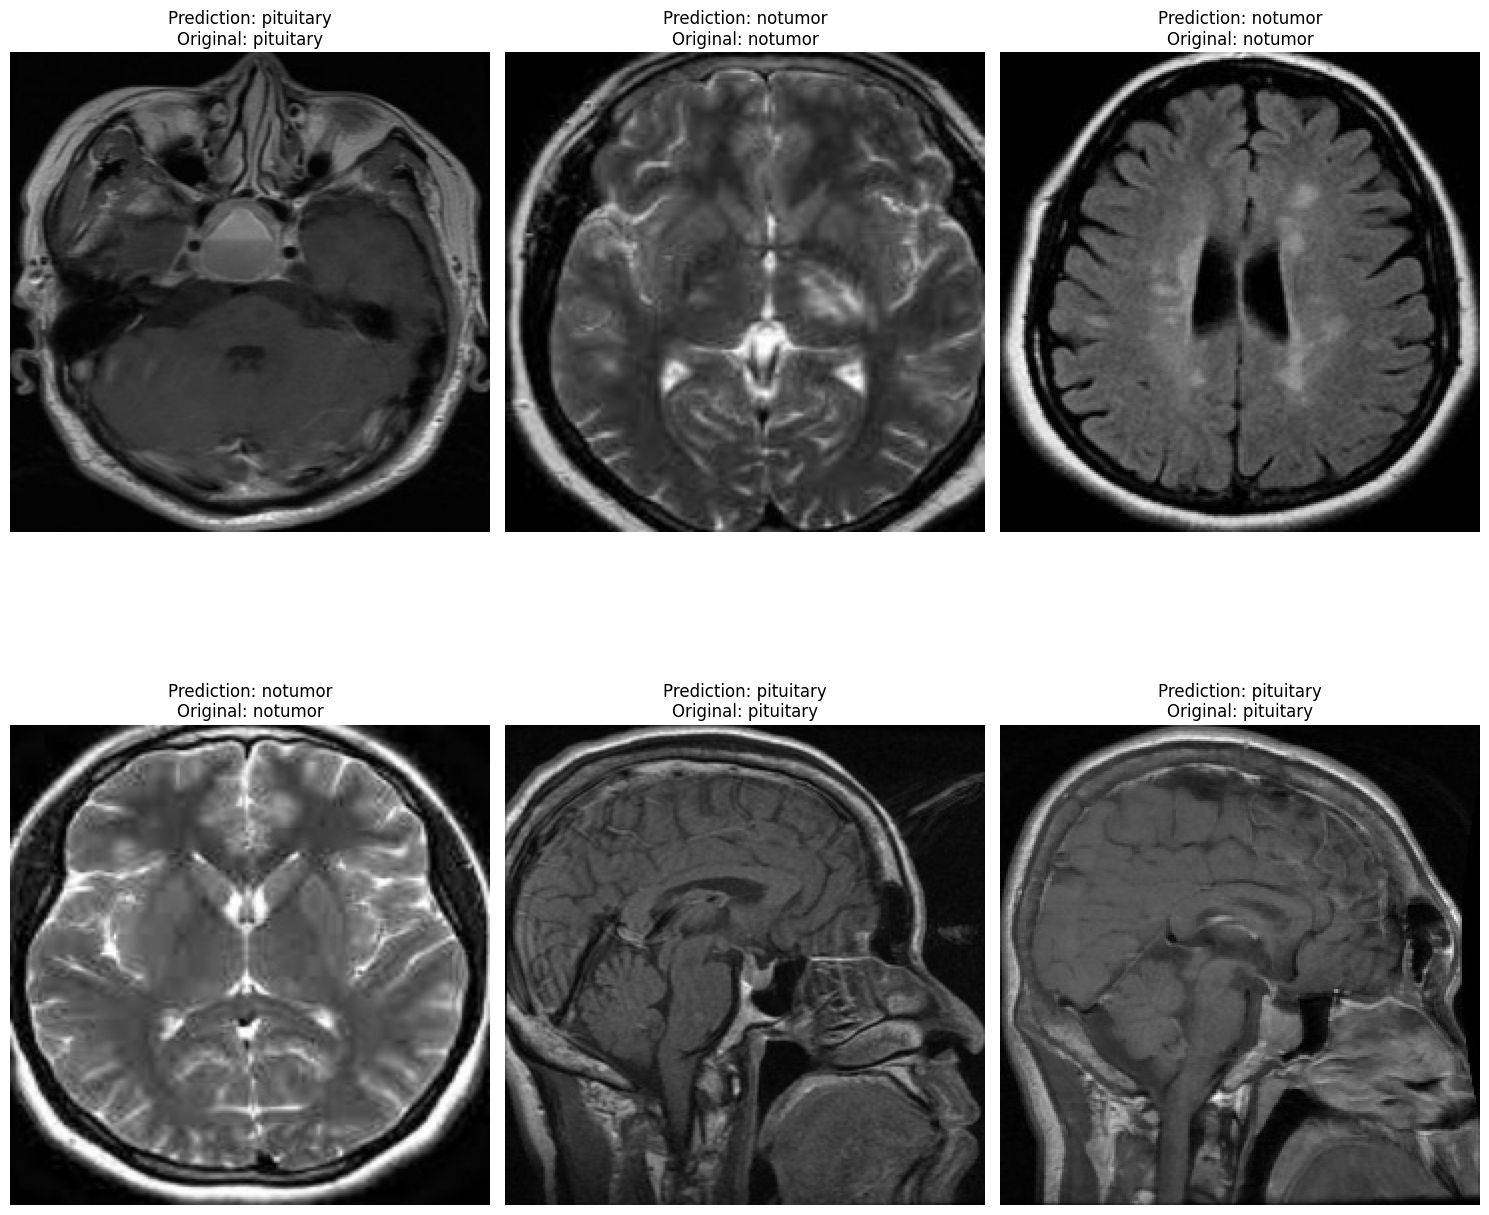

In [ ]:
fig = plt.figure(figsize = (15, 15)) # Adjusted figsize for 6 images

# Display a grid of 6 test images (2 rows, 3 columns)
for i in range(6):
  j = random.randint(0, len(images) - 1)
  fig.add_subplot(2, 3, i+1) # 2 rows, 3 columns
  plt.title(f"Prediction: {prediction[j]}\nOriginal: {original[j]}") # Use title for labels
  plt.axis('off') # Turn off axes
  plt.imshow(images[j])
fig.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, tf.keras.layers.Conv2D))
last_conv_layer.name

'top_conv'

In [ ]:
import cv2
import numpy as np
from PIL import Image
import tensorflow as tf
import tensorflow.keras as K
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.models import Model

def VizGradCAM(model, image, interpolant=0.5):

    assert (
        interpolant > 0 and interpolant < 1
    ), "Heatmap Interpolation Must Be Between 0 - 1"

    last_conv_layer = next(
        x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D)
    )
    target_layer = model.get_layer(last_conv_layer.name)

    original_img = image
    img = np.expand_dims(original_img, axis=0)
    prediction = model.predict(img, verbose=0)

    prediction_idx = np.argmax(prediction)

    with tf.GradientTape() as tape:
        gradient_model = Model([model.inputs], [target_layer.output, model.output])
        conv2d_out, prediction = gradient_model(img)
        loss = prediction[:, prediction_idx]

    gradients = tape.gradient(loss, conv2d_out)

    output = conv2d_out[0]

    weights = tf.reduce_mean(gradients[0], axis=(0, 1))

    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)

    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]

    activation_map = cv2.resize(
        activation_map.numpy(), (original_img.shape[1], original_img.shape[0])
    )

    activation_map = np.maximum(activation_map, 0)

    activation_map = (activation_map - activation_map.min()) / (
        activation_map.max() - activation_map.min()
    )
    activation_map = np.uint8(255 * activation_map)

    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)

    original_img = np.uint8(
        (original_img - original_img.min())
        / (original_img.max() - original_img.min())
        * 255
    )

    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend the original image with the heatmap
    blended_img = np.uint8(original_img * interpolant + cvt_heatmap * (1 - interpolant))
    return blended_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_357']]
Received: inputs=Tensor(shape=(1, 240, 240, 3))
  warnings.warn(msg)


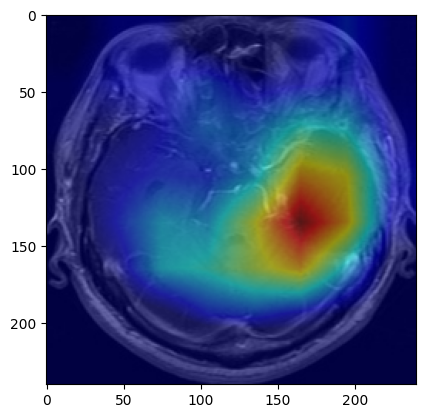

In [ ]:
test_img = cv2.imread("/content/Test-Data/glioma/1.jpg")
VizGradCAM(model, img_to_array(test_img), plot_results=True)

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

def predict_image(image):
    # Preprocess the input image
    img_np = np.array(image)
    img_cv2 = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    # Crop the image
    cropped_img = crop_image(img_cv2, plot=False)

    if cropped_img is None:
        return "Could not process image: No tumor region detected or image is invalid.", None

    # Resize the image to the model's expected input size
    resized_img = cv2.resize(cropped_img, (240, 240))

    # Convert back to RGB for model input if necessary and add batch dimension
    model_input = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
    model_input_for_predict = np.expand_dims(model_input, axis=0)

    # Make prediction
    predictions = model.predict(model_input_for_predict, verbose=0)
    predicted_class_idx = np.argmax(predictions)

    # Map prediction index to class name
    class_labels = list(test_data.class_indices.keys())
    predicted_class_label = class_labels[predicted_class_idx]

    # Generate Grad-CAM visualization
    grad_cam_img = VizGradCAM(model, model_input) # Use model_input directly for Grad-CAM

    return predicted_class_label, grad_cam_img

In [ ]:
iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload MRI Image"),
    outputs=[
        gr.Label(num_top_classes=1, label="Prediction"),
        gr.Image(label="Grad-CAM Visualization")
    ],
    title="Brain Tumor Detection with Grad-CAM",
    description="Upload a brain MRI image to classify if it contains a tumor (glioma, meningioma, pituitary) or no tumor, and see a Grad-CAM visualization.",
    live=True
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56cd36eb4bc6fb926d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
